# Create a logistic regression baseline model to predict stock price movement based on today's stock information

In [1]:
import pandas as pd

In [2]:
stock_df = pd.read_csv("../data/processed/stock_features.csv")

In [3]:
stock_df.head()

,Ticker,Date,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_14,MA_30,Volatility_30,Volume_Change,Price_Movement
0,RELIANCE,2024-05-27,1455.477417,1473.990419,1450.811997,1469.349718,6629010,0.000000,NaN,NaN,NaN,NaN,NaN,0
1,RELIANCE,2024-05-28,1445.501221,1467.637431,1442.076616,1457.214574,7820162,-0.006854,NaN,NaN,NaN,NaN,0.179688,0
2,RELIANCE,2024-05-29,1430.189575,1447.287998,1427.881584,1435.872489,7383556,-0.010593,NaN,NaN,NaN,NaN,-0.055831,0
3,RELIANCE,2024-05-30,1414.381470,1429.817271,1409.666368,1424.953247,13206858,-0.011053,NaN,NaN,NaN,NaN,0.788685,1
4,RELIANCE,2024-05-31,1419.890747,1431.653660,1411.800602,1420.784159,31069832,0.003895,NaN,NaN,NaN,NaN,1.352553,1


In [4]:
stock_df.shape

(1992, 14)

In [5]:
stock_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1992 entries, 0 to 1991
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          1992 non-null   str    
 1   Date            1992 non-null   str    
 2   Close           1992 non-null   float64
 3   High            1992 non-null   float64
 4   Low             1992 non-null   float64
 5   Open            1992 non-null   float64
 6   Volume          1992 non-null   int64  
 7   Daily_Return    1992 non-null   float64
 8   MA_7            1968 non-null   float64
 9   MA_14           1940 non-null   float64
 10  MA_30           1876 non-null   float64
 11  Volatility_30   1876 non-null   float64
 12  Volume_Change   1988 non-null   float64
 13  Price_Movement  1992 non-null   int64  
dtypes: float64(10), int64(2), str(2)
memory usage: 218.0 KB


In [6]:
feature_cols = [
    "Daily_Return",
    "MA_7",
    "MA_14",
    "MA_30",
    "Volatility_30",
    "Volume_Change",
]

### Data Cleaning

In [7]:
import numpy as np

print(f"Shape before cleaning: {stock_df.shape}")

stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.dropna()

print(f"Shape after dropping NaN: {stock_df.shape}")

Shape before cleaning: (1992, 14)
Shape after dropping NaN: (1864, 14)


In [8]:
stock_df.isna().sum()

Ticker            0
Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Daily_Return      0
MA_7              0
MA_14             0
MA_30             0
Volatility_30     0
Volume_Change     0
Price_Movement    0
dtype: int64

In [9]:
features = stock_df[feature_cols]
target = stock_df["Price_Movement"]

### Train-Test split

In [10]:
split_index = int(0.8 * len(stock_df))
X_train, X_test = features[:split_index], features[split_index:]
y_train, y_test = target[:split_index], target[split_index:]

### Logistic Regression

In [11]:
# Standardizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)


In [20]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
print("Logistic Rregression Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Rregression Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.12      0.20       199
           1       0.46      0.87      0.60       174

    accuracy                           0.47       373
   macro avg       0.49      0.49      0.40       373
weighted avg       0.49      0.47      0.39       373

Confusion Matrix:
[[ 24 175]
 [ 23 151]]


### Random Forest

In [14]:
# Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
# Predict and evaluate the Random Forest model
y_rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_rf_pred))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.62      0.57       199
           1       0.44      0.34      0.39       174

    accuracy                           0.49       373
   macro avg       0.48      0.48      0.48       373
weighted avg       0.49      0.49      0.48       373

Random Forest Confusion Matrix:
[[124  75]
 [114  60]]


In [23]:
classification_report(y_test, y_pred, output_dict=True)['accuracy']

0.4691689008042895

## Comparison

In [25]:
# Compare the two models using a table
import pandas as pd
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        classification_report(y_test, y_pred, output_dict=True)["accuracy"],
        classification_report(y_test, y_rf_pred, output_dict=True)["accuracy"],
    ],
    "Precision": [
        classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["precision"],
        classification_report(y_test, y_rf_pred, output_dict=True)["weighted avg"]["precision"],
    ],
    "Recall": [
        classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_rf_pred, output_dict=True)["weighted avg"]["recall"],
    ],
    "F1-Score": [
        classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["f1-score"],
        classification_report(y_test, y_rf_pred, output_dict=True)["weighted avg"]["f1-score"],
    ],
})
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.469169,0.488504,0.469169,0.385859
1,Random Forest,0.493298,0.485292,0.493298,0.483932


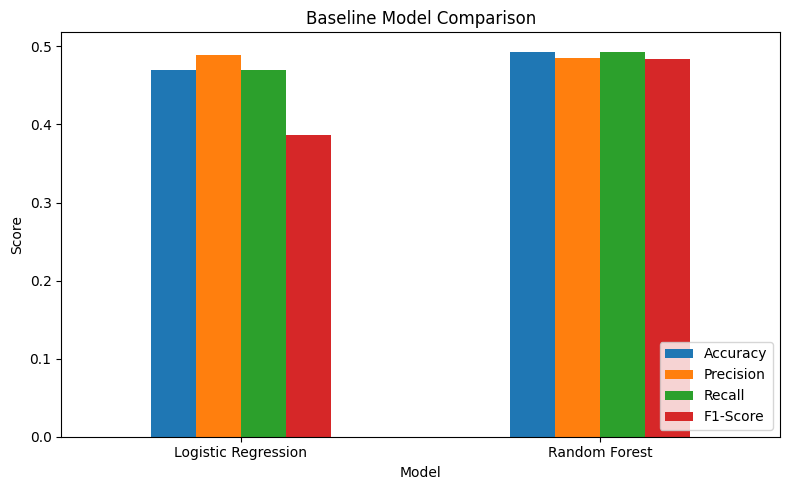

In [26]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

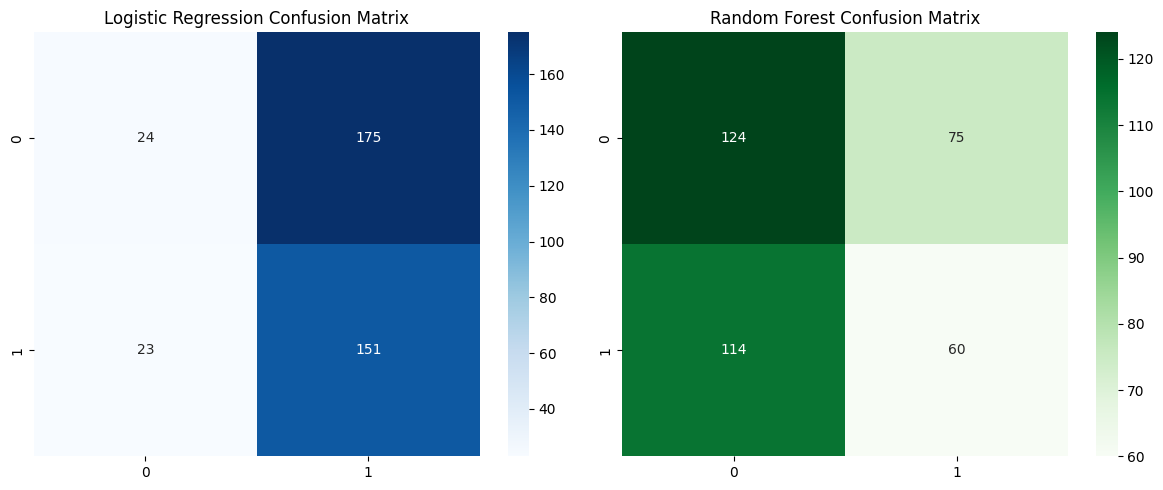

In [28]:
# Plot confusion matrices for both models
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_rf_pred), annot=True, fmt="d", ax=axes[1], cmap="Greens")
axes[1].set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()  